## 0.8 디랙 표기법과 큐비트 상태

켓·브라·내적, Born 규칙·정규화, 블로흐 구를 확인하고, 심화로 외적·사영연산자·완전성 관계를 검증한다. Part 0의 종착점이다.

### 0.8.1 켓·브라와 내적

In [1]:
import numpy as np

ket0 = np.array([[1],[0]],dtype=complex); ket1 = np.array([[0],[1]],dtype=complex)
alpha=(1+1j)/2; beta=1/np.sqrt(2)
psi = alpha*ket0 + beta*ket1
bra = psi.conj().T               # 브라 = 켓의 켤레전치
print("|psi> =\n", psi)
print("<psi|psi> =", np.round((bra@psi)[0,0],6))   # 1 (정규화)

|psi> =
 [[0.5       +0.5j]
 [0.70710678+0.j ]]
<psi|psi> = (1+0j)


### 0.8.2 확률 진폭과 Born 규칙

In [2]:
import numpy as np

alpha=(1+1j)/2; beta=1/np.sqrt(2)
assert np.isclose(abs(alpha)**2+abs(beta)**2, 1.0)
print("정규화 |α|²+|β|² = 1 확인")
print("P(0)=|α|² =", round(abs(alpha)**2,4), ", P(1)=|β|² =", round(abs(beta)**2,4))

정규화 |α|²+|β|² = 1 확인
P(0)=|α|² = 0.5 , P(1)=|β|² = 0.5


### 0.8.3 블로흐 구

측정 확률: {np.str_('0'): np.float64(0.7500000000000001), np.str_('1'): np.float64(0.2499999999999999)}


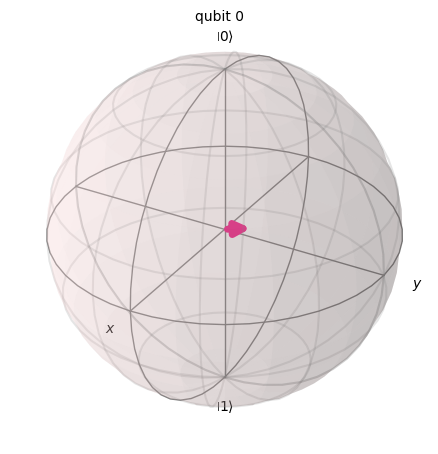

In [3]:
import numpy as np
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector
import matplotlib.pyplot as plt
%matplotlib inline

theta, phi = np.radians(60), np.radians(40)
sv = Statevector([np.cos(theta/2), np.exp(1j*phi)*np.sin(theta/2)])
print("측정 확률:", sv.probabilities_dict())
plot_bloch_multivector(sv); plt.show()

### 0.8.4 심화: 외적·사영연산자와 완전성 관계
|ψ⟩⟨φ|는 외적(행렬)이고, |i⟩⟨i|는 사영연산자다. 정규직교 기저의 사영연산자를 모두 더하면 항등이 된다(Σ|i⟩⟨i|=I).

In [4]:
import numpy as np

ket0 = np.array([[1],[0]],dtype=complex); ket1 = np.array([[0],[1]],dtype=complex)
P0 = ket0 @ ket0.conj().T   # |0><0| 사영연산자
P1 = ket1 @ ket1.conj().T   # |1><1|
print("|0><0| =\n", P0.real)
print("완전성 Σ|i><i| = I ?", np.allclose(P0+P1, np.eye(2)))

|0><0| =
 [[1. 0.]
 [0. 0.]]
완전성 Σ|i><i| = I ? True


In [5]:
import numpy as np

# 측정 확률 = <psi|P|psi> (사영을 통한 Born 규칙)
alpha=(1+1j)/2; beta=1/np.sqrt(2)
psi = alpha*np.array([[1],[0]],dtype=complex) + beta*np.array([[0],[1]],dtype=complex)
P0 = np.array([[1,0],[0,0]]); P1 = np.array([[0,0],[0,1]])
p0 = (psi.conj().T @ P0 @ psi)[0,0].real
p1 = (psi.conj().T @ P1 @ psi)[0,0].real
print("P(0)=<psi|P0|psi> =", round(p0,4))
print("P(1)=<psi|P1|psi> =", round(p1,4))
print("합 =", round(p0+p1,6), " -> 외적·사영·측정·완전성이 하나로 이어진다")

P(0)=<psi|P0|psi> = 0.5
P(1)=<psi|P1|psi> = 0.5
합 = 1.0  -> 외적·사영·측정·완전성이 하나로 이어진다
